In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


LOADING THE DATASET

In [89]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv(url, sep=';', header=None)

# Features
X = data.iloc[:, :-1].values

# Target
y = data.iloc[:, -1].values

y = np.where(y == "RB", 1, -1)

print("Dataset Shape:", X.shape)

Dataset Shape: (1055, 41)


SPLITTING THE DATA

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SCALING THE DATA

In [91]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

IMPLEMENTING SVM

In [92]:
class LinearSVM:

    def __init__(
        self,
        learning_rate=0.001, 
        lambda_param=0.01, 
        n_iters=1000
    ):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters

        self.w = None
        self.b = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):

            for idx, x_i in enumerate(X):

                condition = (
                    y[idx] *
                    (np.dot(x_i, self.w) + self.b)
                    >= 1
                )

                if condition:

                    dw = 2 * self.lambda_param * self.w
                    db = 0

                else:

                    dw = (
                        2 * self.lambda_param * self.w
                        - y[idx] * x_i
                    )

                    db = -y[idx]

                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):

        linear_output = np.dot(X, self.w) + self.b

        return np.sign(linear_output)

    def decision_function(self, X):

        return np.dot(X, self.w) + self.b


TRAINING THE MODEL

In [93]:
svm = LinearSVM(
    learning_rate=0.001,
    lambda_param=0.01,
    n_iters=1000
)

svm.fit(X_train, y_train)

PREDICTIONS & ACCURACY

In [94]:
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


Accuracy: 86.26 %


CONFUSION MATRIX & CLASSIFICATION REPORT


Confusion Matrix:


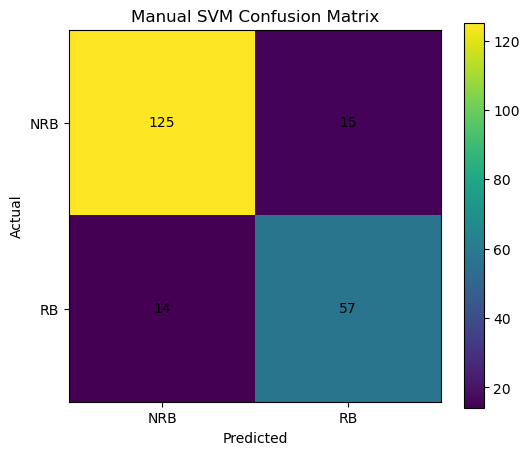


Classification Report:
              precision    recall  f1-score   support

          -1       0.90      0.89      0.90       140
           1       0.79      0.80      0.80        71

    accuracy                           0.86       211
   macro avg       0.85      0.85      0.85       211
weighted avg       0.86      0.86      0.86       211



In [95]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Manual SVM Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["NRB","RB"])
plt.yticks([0,1], ["NRB","RB"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [96]:
svm = LinearSVM(
    learning_rate=0.001,
    lambda_param=0.00001,
    n_iters=10000
)

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


Accuracy: 86.73 %


SVM USING SCIKIT-LEARN

In [97]:
svm = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8578199052132701


c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CONFUSION MATRIX

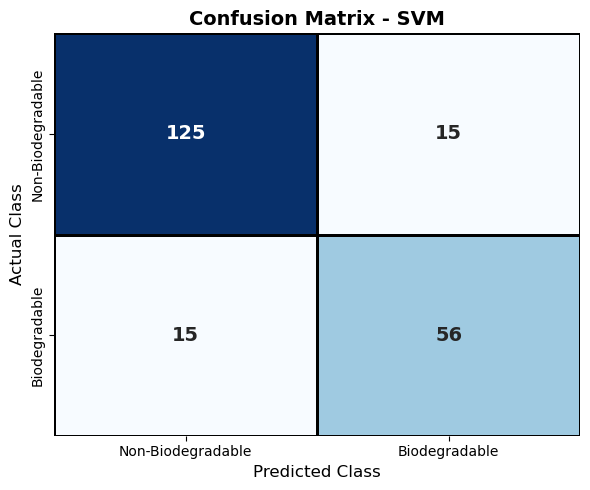


Classification Report:
              precision    recall  f1-score   support

          -1       0.89      0.89      0.89       140
           1       0.79      0.79      0.79        71

    accuracy                           0.86       211
   macro avg       0.84      0.84      0.84       211
weighted avg       0.86      0.86      0.86       211



In [98]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.title('Confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)

for text in plt.gca().texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
